# 06 — Shadow Validation of the Locked Champion

Checks that the locked **LightGBM / RAW / F4** price model behaves correctly on new data, the way it would
in production: predict first **without** the target, then compare with trusted actual rents.

| | |
|---|---|
| **Objective** | Verify the inference contract, monitor drift and error, and decide production readiness. |
| **Input** | Locked champion in `data/modeling/roombeacon_price_benchmark_v3/` + canonical Silver |
| **Output** | Monitoring evidence; append-only run files are written only by section 21 (`skip-execution`) |
| **Out of scope** | Training, tuning or re-selecting a model (Notebook 04 only) |

The current data is a `HISTORICAL_DRY_RUN` (it overlaps the model's training period), so it proves the
mechanics but **cannot** count as production evidence; only a wholly new post-lock batch becomes
`FUTURE_SHADOW` evidence.

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB06 current
```

The highlighted step is this notebook.

## 01. Purpose and Contract

```mermaid
flowchart LR
    A[("Locked champion<br/>model + metadata")] --> C["Build target-free<br/>F4 matrix"]
    S[("Silver batch")] --> R["Inference-ready rows"] --> C
    C --> P["predict()"]
    P --> J["THEN join trusted<br/>actual rent"]
    J --> M["Drift · error · calibration"]
    M --> G{"Readiness gate"}
```

Notebook 04 owns training and selection; this notebook only loads the immutable artifact. The actual rent
is never visible to the model — it is joined after prediction, for monitoring only.

## 02. Runtime Configuration

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

import json
import platform
from datetime import datetime, timezone

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.modeling_benchmark import build_modeling_eligibility
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    NEUTRAL,
    STATUS,
    apply_style,
    bar_chart,
    funnel_chart,
    histogram,
    scatter_legend,
)
from notebooks.utils.shadow_validation import *  # noqa: F403 — shadow-validation contract helpers

SEED = 42
np.random.seed(SEED)
apply_style()
BENCHMARK_DIR = PROJECT_ROOT / "data" / "modeling" / "roombeacon_price_benchmark_v3"
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / "rental_listings.parquet"
SHADOW_OUTPUT_ROOT = PROJECT_ROOT / "data" / "modeling" / "shadow_validation"
MIN_SUPPORT = 100
INFERENCE_TIMESTAMP = datetime.now(timezone.utc).isoformat()
display(
    pd.Series(
        {"Python": platform.python_version(), "Minimum slice support": MIN_SUPPORT}, name="value"
    ).to_frame()
)

,value
Python,3.12.3
Minimum slice support,100


## 03. Load Champion Artifact

> **Why:** verify the exact model, features and parameters before using it.

In [2]:
champion = resolve_champion_artifact(BENCHMARK_DIR)
display(
    pd.Series(
        {
            "model_id": champion.metadata["model_id"],
            "family / transform": f"{champion.metadata['model_family']} / {champion.metadata['target_transform']}",
            "feature set": champion.metadata["feature_set"],
            "features": ", ".join(champion.metadata["feature_names"]),
            "parameters": json.dumps(champion.metadata["hyperparameters"], sort_keys=True),
            "artifact SHA-256": champion.metadata["artifact_sha256"],
            "reference population": f"{champion.reference_profile['population']} ({champion.reference_profile['row_count']:,} rows)",
            "reference range": f"{champion.reference_profile['min_observed_at']} → {champion.reference_profile['max_observed_at']}",
        },
        name="locked champion",
    ).to_frame()
)

,locked champion
model_id,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450
family / transform,LightGBM Regressor / RAW
feature set,F4 — AREA + SOURCE + LOCATION
features,"area_value_clean, source_code, ward_current, d..."
parameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3..."
artifact SHA-256,0b0c9d9fa450fa6f969184c220fc06a9f5434e5cd44af9...
reference population,"DEVELOPMENT (95,731 rows)"
reference range,2026-09-20T12:48:44 → 2026-09-29T12:53:17


## 04. Load Canonical Silver / Shadow Batch

> **Why:** decide whether this batch is new evidence (`FUTURE_SHADOW`) or a replay of known data (`HISTORICAL_DRY_RUN`).

In [3]:
with duckdb.connect(":memory:") as connection:
    silver_df = connection.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()
assert len(silver_df) == silver_df.rental_post_id.nunique()

evidence_cutoff = champion.metadata["training_reference"]["evidence_cutoff"]
mode_decision = classify_validation_mode(silver_df.latest_observed_at, evidence_cutoff)
VALIDATION_MODE = mode_decision.mode
CURRENT_SILVER_SHA256 = file_sha256(SILVER_PATH)
display(
    pd.Series(
        {
            "Silver rows": f"{len(silver_df):,}",
            "Observed range": f"{pd.to_datetime(silver_df.latest_observed_at).min()} → {pd.to_datetime(silver_df.latest_observed_at).max()}",
            "Model-lock evidence cutoff": evidence_cutoff,
            "Validation mode": VALIDATION_MODE,
            "Counts toward production evidence": mode_decision.counts_toward_production,
            "Reason": mode_decision.reason,
        },
        name="shadow batch",
    ).to_frame()
)
if CURRENT_SILVER_SHA256 == champion.metadata["training_reference"]["silver_sha256"]:
    assert (
        VALIDATION_MODE == "HISTORICAL_DRY_RUN"
    ), "The champion-development snapshot must remain a historical dry run"

,shadow batch
Silver rows,"132,494"
Observed range,2026-09-20 12:48:44 → 2026-10-03 09:57:20
Model-lock evidence cutoff,2026-09-30T10:42:53
Validation mode,HISTORICAL_DRY_RUN
Counts toward production evidence,False
Reason,Batch is historical or mixed relative to the m...


## 05. Validate Inference Schema

> **Why:** only rows with every F4 input can be scored; the rest are counted, not silently dropped.

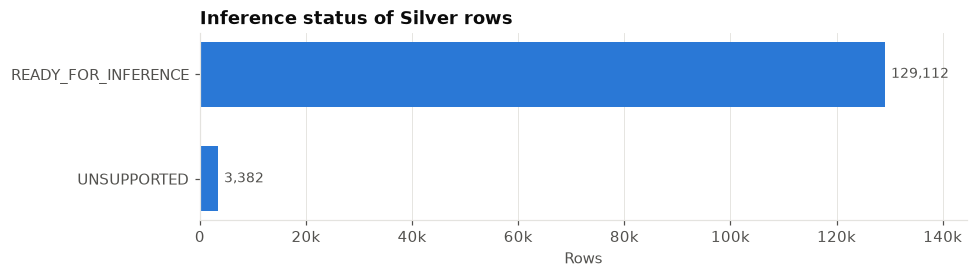

,Status,Reason,Rows
0,READY_FOR_INFERENCE,SCHEMA_VALID,129112


In [4]:
population = prepare_shadow_population(silver_df, champion.metadata, policy="PERMISSIVE")
assert len(population.all_rows) == len(silver_df)
assert len(population.ready_rows) == int(
    population.all_rows.inference_status.eq("READY_FOR_INFERENCE").sum()
)
bar_chart(
    population.all_rows.inference_status.value_counts(dropna=False),
    title="Inference status of Silver rows",
    xlabel="Rows",
)
plt.show()
display(population.schema_summary)

## 06. Build F4 Features

In [5]:
X_shadow = build_inference_matrix(population.ready_rows, champion.metadata)
display(
    pd.DataFrame(
        {
            "Feature": X_shadow.columns,
            "Runtime dtype": [str(dtype) for dtype in X_shadow.dtypes],
            "Expected type": [
                champion.metadata["expected_schema"][column] for column in X_shadow.columns
            ],
        }
    )
)
assert X_shadow.columns.tolist() == champion.metadata["feature_names"] == list(F4_FEATURES)
assert TARGET_COLUMN not in X_shadow.columns
assert len(X_shadow) == len(population.ready_rows)

,Feature,Runtime dtype,Expected type
0,area_value_clean,float64,numeric
1,source_code,category,categorical
2,ward_current,category,categorical
3,district_text_extracted,category,categorical


## 07. Reference vs Shadow Population

> **Why:** show how many rows can be scored and how many can also be evaluated (this is a serving funnel, not a drift metric).

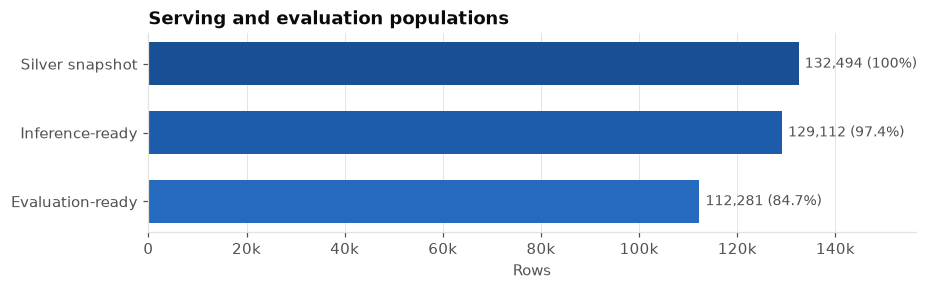

In [6]:
eval_rows_count = int(
    build_modeling_eligibility(silver_df, policy="PERMISSIVE").final_eligible.sum()
)
funnel_chart(
    pd.Series(
        {
            "Silver snapshot": len(silver_df),
            "Inference-ready": len(population.ready_rows),
            "Evaluation-ready": eval_rows_count,
        }
    ),
    title="Serving and evaluation populations",
)
plt.show()

## 08. Feature Drift

> **Why:** if area looks different from the training reference, error estimates from Notebook 04 may no longer hold.

,Feature,Reference Median,Shadow Median,Median Shift,Reference IQR,Shadow IQR,IQR Shift,Reference P95,Shadow P95,P95 Shift,Reference Missing %,Shadow Missing %,Missing Shift pp
0,area_value_clean,28.0,28.0,0.0,13.0,13.0,0.0,50.0,50.0,0.0,0.0,0.0,0.0


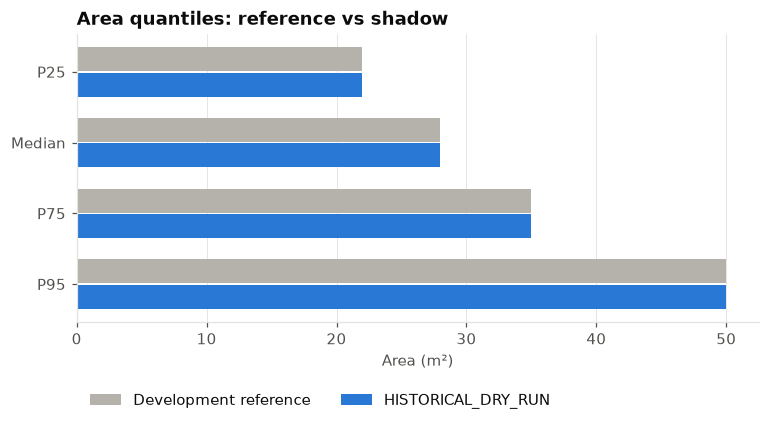

In [7]:
numeric_drift, category_share_drift = feature_drift_report(
    population.ready_rows, champion.reference_profile
)
display(numeric_drift)
reference_area = champion.reference_profile["numeric"]["area_value_clean"]
shadow_area = population.ready_rows.area_value_clean.astype(float)
quantiles = pd.DataFrame(
    {
        "Reference": [
            reference_area["p25"],
            reference_area["median"],
            reference_area["p75"],
            reference_area["p95"],
        ],
        VALIDATION_MODE: [
            shadow_area.quantile(0.25),
            shadow_area.median(),
            shadow_area.quantile(0.75),
            shadow_area.quantile(0.95),
        ],
    },
    index=["P25", "Median", "P75", "P95"],
)
fig, ax = plt.subplots(figsize=(8, 3.4))
positions = np.arange(len(quantiles))
ax.barh(
    positions - 0.18,
    quantiles["Reference"],
    height=0.34,
    color=NEUTRAL,
    label="Development reference",
)
ax.barh(
    positions + 0.18,
    quantiles[VALIDATION_MODE],
    height=0.34,
    color=CATEGORICAL[0],
    label=VALIDATION_MODE,
)
ax.set_yticks(positions, quantiles.index)
ax.invert_yaxis()
ax.set(title="Area quantiles: reference vs shadow", xlabel="Area (m²)")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=2)
plt.show()

## 09. Category Drift

> **Why:** a shift in source mix or unseen wards changes what the model is asked to predict.

,Feature,Reference Category Count,Shadow Category Count,Unseen Category Count,Unseen Categories,Unseen Rows,Unseen Row %,Reference Missing %,Shadow Missing %,Missing Shift pp
0,source_code,6,6,0,[],0,0.000000,0.000000,0.000000,0.000000
1,ward_current,78,78,0,[],0,0.000000,34.622014,32.417591,-2.204423
2,district_text_extracted,53,54,1,"[""Quận TB""]",1,0.000775,36.435428,33.795464,-2.639964


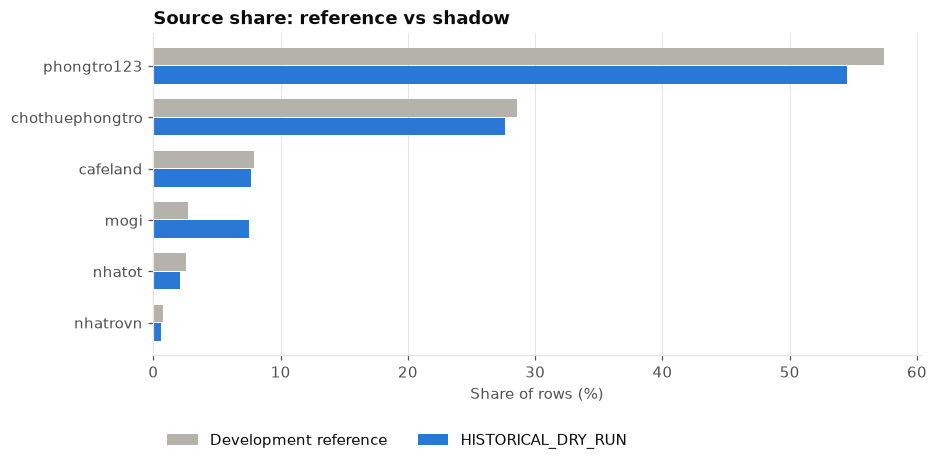

In [8]:
category_drift = category_drift_report(population.ready_rows, champion.reference_profile)
display(category_drift)
source_share = category_share_drift.loc[category_share_drift.Feature.eq("source_code")].sort_values(
    "Reference Share %", ascending=False
)
fig, ax = plt.subplots(figsize=(9, 3.8))
positions = np.arange(len(source_share))
ax.barh(
    positions - 0.18,
    source_share["Reference Share %"],
    height=0.34,
    color=NEUTRAL,
    label="Development reference",
)
ax.barh(
    positions + 0.18,
    source_share["Shadow Share %"],
    height=0.34,
    color=CATEGORICAL[0],
    label=VALIDATION_MODE,
)
ax.set_yticks(positions, source_share.Category)
ax.invert_yaxis()
ax.set(title="Source share: reference vs shadow", xlabel="Share of rows (%)")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=2)
plt.show()

## 10. Run Shadow Inference

> **Why:** score every inference-ready row with the target absent.

In [9]:
shadow_predictions = predict_shadow(
    champion.model, population.ready_rows, champion.metadata, VALIDATION_MODE, INFERENCE_TIMESTAMP
)
assert len(shadow_predictions) == len(population.ready_rows)
assert shadow_predictions.rental_post_id.tolist() == population.ready_rows.rental_post_id.tolist()
display(
    pd.Series(
        {
            "Prediction rows": f"{len(shadow_predictions):,}",
            "Model ID": champion.metadata["model_id"],
            "Target present during prediction": TARGET_COLUMN in X_shadow.columns,
        },
        name="inference",
    ).to_frame()
)
shadow_predictions.head()

,inference
Prediction rows,"129,112"
Model ID,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450
Target present during prediction,False


,rental_post_id,observed_at,area_value_clean,source_code,ward_current,district_text_extracted,predicted_monthly_rent,model_version,model_id,validation_mode,inference_timestamp
0,53598,2026-09-28 07:50:50,16.0,mogi,NaN,Quận 3,3.040911e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-08T07:38:51.001758+00:00
1,53599,2026-09-25 20:20:14,17.0,mogi,Phường Bàn Cờ,Quận 3,3.630393e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-08T07:38:51.001758+00:00
2,53600,2026-09-28 07:45:33,30.0,mogi,Phường Gia Định,Quận Bình Thạnh,4.990402e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-08T07:38:51.001758+00:00
3,53601,2026-09-28 09:44:50,35.0,mogi,NaN,Quận Tân Bình,3.835522e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-08T07:38:51.001758+00:00
4,53602,2026-09-28 09:44:50,30.0,mogi,NaN,Quận Tân Bình,3.850609e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-08T07:38:51.001758+00:00


## 11. Prediction Sanity

> **Why:** catch impossible outputs (negative, zero, absurd) before measuring error.

,Check,Status
0,Prediction count matches inference-ready rows,PASS
1,Prediction IDs are unique,PASS
2,No missing predictions,PASS
3,All predictions are finite,PASS
4,No negative predictions,PASS


,Population,count,min,p01,p25,median,p75,p95,p99,max
0,DEVELOPMENT_REFERENCE,95731.0,514492.913765,1.841901e+06,3.462905e+06,4.050359e+06,5.000115e+06,5.699392e+06,6.588095e+06,7.197122e+06
1,HISTORICAL_DRY_RUN,129112.0,514492.913765,1.809662e+06,3.462905e+06,4.052660e+06,5.000002e+06,5.719635e+06,6.644311e+06,7.197122e+06


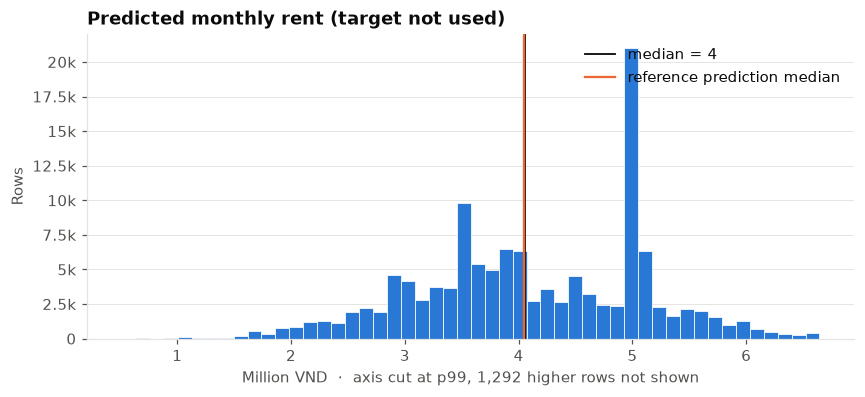

In [10]:
sanity_checks = prediction_sanity_report(shadow_predictions, len(population.ready_rows))
prediction_distribution_table = prediction_distribution(shadow_predictions)
reference_prediction = champion.reference_profile.get("prediction") or {}
prediction_reference_comparison = pd.DataFrame(
    [
        {"Population": "DEVELOPMENT_REFERENCE", **reference_prediction},
        {"Population": VALIDATION_MODE, **prediction_distribution_table.iloc[0].to_dict()},
    ]
)
display(sanity_checks)
display(prediction_reference_comparison)
assert sanity_checks.Status.eq("PASS").all()

ax = histogram(
    shadow_predictions.predicted_monthly_rent / 1e6,
    title="Predicted monthly rent (target not used)",
    xlabel="Million VND",
)
if reference_prediction.get("median") is not None:
    ax.axvline(
        reference_prediction["median"] / 1e6,
        color=CATEGORICAL[1],
        linewidth=1.5,
        label="reference prediction median",
    )
    ax.legend(loc="upper right")
plt.show()

## 12. Overall Error Metrics

> **Why:** now — and only now — join trusted actual rent and measure error. Residual = prediction − actual (positive = over-prediction).

In [11]:
evaluation_population = prepare_evaluation_population(
    shadow_predictions, silver_df, policy="PERMISSIVE", target_column=TARGET_COLUMN
)
shadow_output = evaluation_population.all_predictions
evaluation_frame = evaluation_population.evaluation_predictions
assert len(shadow_output) == len(shadow_predictions)
assert len(evaluation_frame) == int(
    evaluation_population.funnel.loc[
        evaluation_population.funnel.Stage.eq("Final model eligible"), "Rows"
    ].iloc[0]
)
overall_metrics = pd.DataFrame([evaluate_shadow_predictions(evaluation_frame)])
display(evaluation_population.exclusion_summary)
display(overall_metrics)

,Reason,Rows
0,MODEL_ELIGIBLE,112281
1,TARGET_LINEAGE_NOT_TRUSTED,9163
2,PRICE_SEMANTIC_NOT_SUPPORTED,4450
3,NO_NUMERIC_TARGET_CANDIDATE,4376
4,AREA_NOT_SUPPORTED,2224


,Rows,MAE,MedianAE,RMSE,RMSLE,R²,Signed Bias,Underprediction %,Overprediction %,Exact Match %
0,112281,1.079233e+06,694133.599575,1.679092e+06,0.454236,0.270482,-39386.794483,49.626384,50.373616,0.0


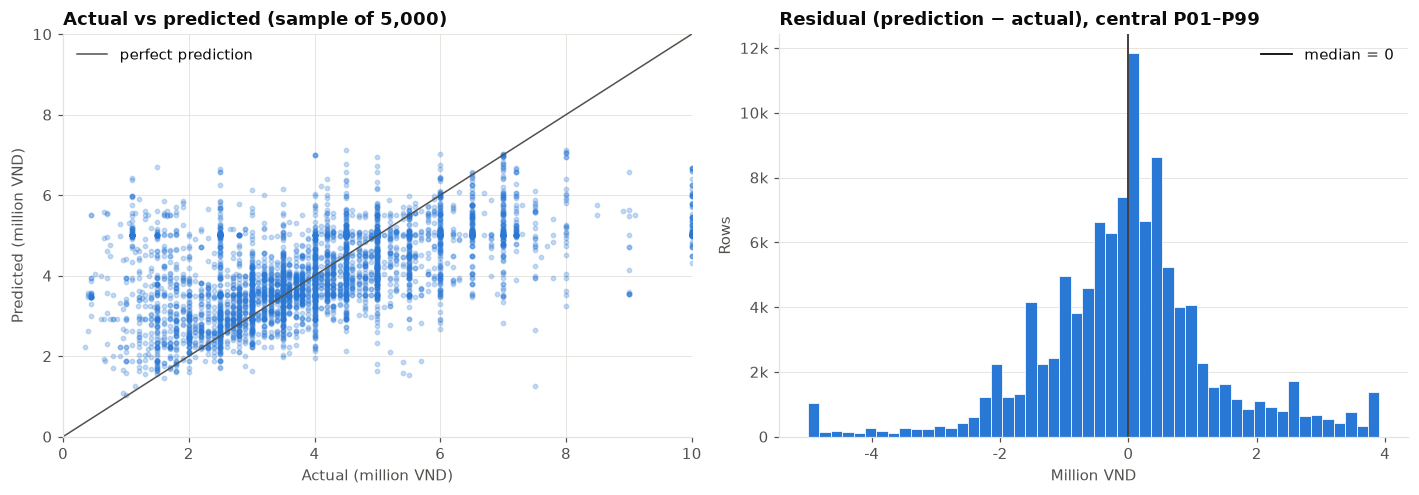

2,106 residuals fall outside the displayed range; all are kept in the metrics.

In [12]:
evaluated = evaluation_frame.loc[evaluation_frame.actual_monthly_rent.notna()].copy()
sample = (
    evaluated.sample(min(5000, len(evaluated)), random_state=SEED) if len(evaluated) else evaluated
)
limit = evaluated.actual_monthly_rent.quantile(0.99) / 1e6 if len(evaluated) else 1

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.6))
left.scatter(
    sample.actual_monthly_rent / 1e6,
    sample.predicted_monthly_rent / 1e6,
    s=8,
    alpha=0.25,
    color=CATEGORICAL[0],
)
left.plot([0, limit], [0, limit], color="#52514e", linewidth=1, label="perfect prediction")
left.set(
    xlim=(0, limit),
    ylim=(0, limit),
    title=f"Actual vs predicted (sample of {len(sample):,})",
    xlabel="Actual (million VND)",
    ylabel="Predicted (million VND)",
)
left.grid(axis="y")
left.legend(loc="upper left")

p01_res, p99_res = evaluated.residual.quantile([0.01, 0.99])
central_res = evaluated.loc[evaluated.residual.between(p01_res, p99_res), "residual"]
histogram(
    central_res / 1e6,
    title="Residual (prediction − actual), central P01–P99",
    xlabel="Million VND",
    clip_quantile=None,
    ax=right,
)
right.axvline(0, color="#52514e", linewidth=1)
plt.tight_layout()
plt.show()
display(
    Markdown(
        f"{len(evaluated) - len(central_res):,} residuals fall outside the displayed range; all are kept in the metrics."
    )
)

## 13. Price-Bucket Diagnostics

> **Why:** a single MAE hides whether cheap or expensive rooms are mispriced.

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Actual Price Bucket,< 2.5M,17414,15.509303,1600000.0,3.245253e+06,1.826097e+06,1.517666e+06,1.808666e+06
1,Actual Price Bucket,2.5M–<4.0M,36565,32.565617,3200000.0,3.525735e+06,6.693685e+05,4.397769e+05,4.284219e+05
2,Actual Price Bucket,4.0M–<6.0M,39491,35.171578,4500000.0,4.470785e+06,6.324443e+05,5.046968e+05,-3.006459e+05
3,Actual Price Bucket,6.0M–10.0M,15936,14.192962,6500000.0,5.005291e+06,1.595101e+06,1.499998e+06,-1.581585e+06
4,Actual Price Bucket,> 10.0M,2875,2.560540,10000000.0,5.025478e+06,5.045848e+06,4.986782e+06,-5.045848e+06


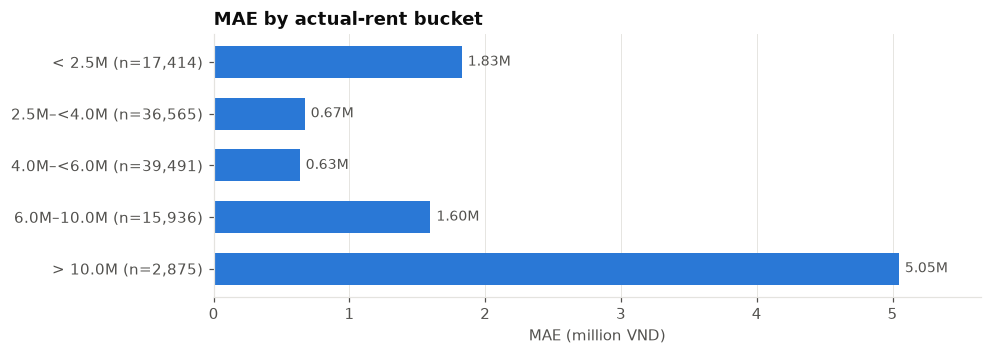

In [13]:
price_diagnostics = price_bucket_diagnostics(evaluation_frame)
display(price_diagnostics)
bar_chart(
    price_diagnostics.set_index(
        price_diagnostics.Segment + " (n=" + price_diagnostics.Rows.map("{:,}".format) + ")"
    )["MAE"]
    / 1e6,
    title="MAE by actual-rent bucket",
    xlabel="MAE (million VND)",
    sort=False,
    fmt="{:.2f}M",
)
plt.show()

## 14. Area-Bucket Diagnostics

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Area Bucket,Small <15m²,4278,3.810084,2100000.0,2.109402e+06,7.150204e+05,5.040497e+05,-131853.653839
1,Area Bucket,Compact 15–<25m²,28033,24.966824,3200000.0,3.212652e+06,8.043115e+05,5.799810e+05,-29180.618404
2,Area Bucket,Standard 25–<40m²,64885,57.788050,4500000.0,4.499503e+06,1.124758e+06,7.145869e+05,-36926.763961
3,Area Bucket,Large 40–80m²,12906,11.494376,5000000.0,4.999902e+06,1.492272e+06,1.020417e+06,18917.452235
4,Area Bucket,Very large >80m²,2179,1.940667,2900000.0,2.992987e+06,1.529148e+06,9.063630e+05,-407734.751442


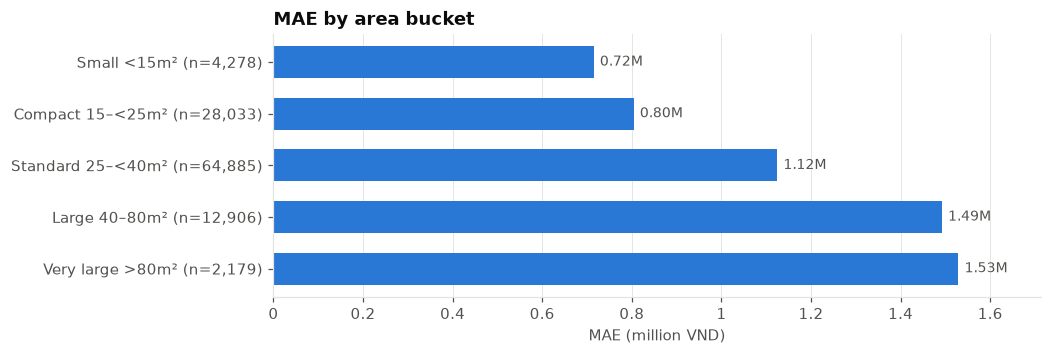

In [14]:
area_diagnostics = area_bucket_diagnostics(evaluation_frame)
display(area_diagnostics)
bar_chart(
    area_diagnostics.set_index(
        area_diagnostics.Segment + " (n=" + area_diagnostics.Rows.map("{:,}".format) + ")"
    )["MAE"]
    / 1e6,
    title="MAE by area bucket",
    xlabel="MAE (million VND)",
    sort=False,
    fmt="{:.2f}M",
)
plt.show()

## 15. Source Diagnostics

> **Why:** check that no single source is systematically mispriced (sources with fewer than `MIN_SUPPORT` rows are not shown).

,Dimension,Segment,Evaluation Rows,Share %,Actual Median,Prediction Median,Evaluation MAE,Evaluation MedianAE,Evaluation Signed Bias,Inference Reference Share %,Inference Shadow Share %,Delta pp
0,Source,phongtro123,69138,61.575868,3500000.0,3.612666e+06,8.509751e+05,5.844273e+05,29699.253619,57.417138,54.491449,-2.925688
1,Source,chothuephongtro,27402,24.404841,5000000.0,5.005291e+06,1.725297e+06,1.458982e+06,-204697.882117,28.606199,27.624078,-0.982120
2,Source,cafeland,9354,8.330884,4000000.0,4.080374e+06,8.993476e+05,6.482343e+05,-95513.720117,7.925332,7.680154,-0.245179
3,Source,mogi,2987,2.660290,3600000.0,3.920232e+06,1.171475e+06,7.306097e+05,163728.442285,2.739969,7.528347,4.788378
4,Source,nhatot,2622,2.335213,3700000.0,3.777605e+06,9.118562e+05,5.824952e+05,-54652.569759,2.586414,2.073394,-0.513020
5,Source,nhatrovn,778,0.692904,4500000.0,4.344151e+06,9.812588e+05,7.004737e+05,-409931.598334,0.724948,0.602578,-0.122370


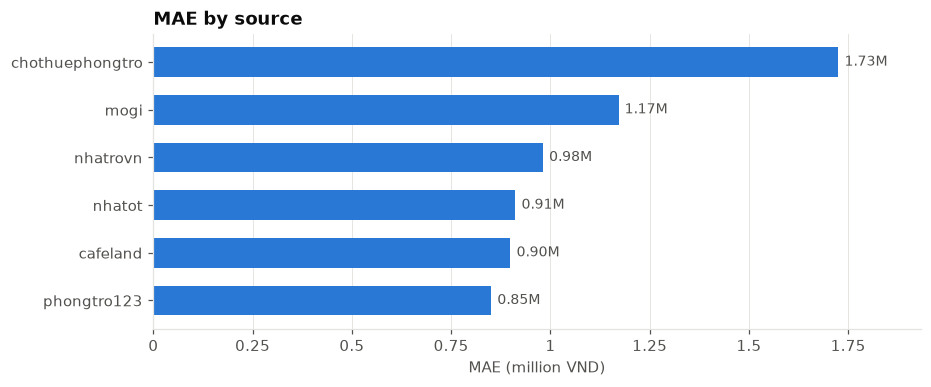

In [15]:
source_metrics = source_diagnostics(evaluation_frame, min_support=MIN_SUPPORT)
source_metrics = source_metrics.merge(
    source_share[["Category", "Reference Share %", "Shadow Share %", "Delta pp"]],
    left_on="Segment",
    right_on="Category",
    how="left",
).drop(columns=["Category"])
source_metrics = source_metrics.rename(
    columns={
        "Reference Share %": "Inference Reference Share %",
        "Shadow Share %": "Inference Shadow Share %",
        "Rows": "Evaluation Rows",
        "MAE": "Evaluation MAE",
        "MedianAE": "Evaluation MedianAE",
        "Signed Bias": "Evaluation Signed Bias",
    }
)
display(source_metrics)
bar_chart(
    source_metrics.set_index("Segment")["Evaluation MAE"] / 1e6,
    title="MAE by source",
    xlabel="MAE (million VND)",
    fmt="{:.2f}M",
)
plt.show()

## 16. Location Diagnostics

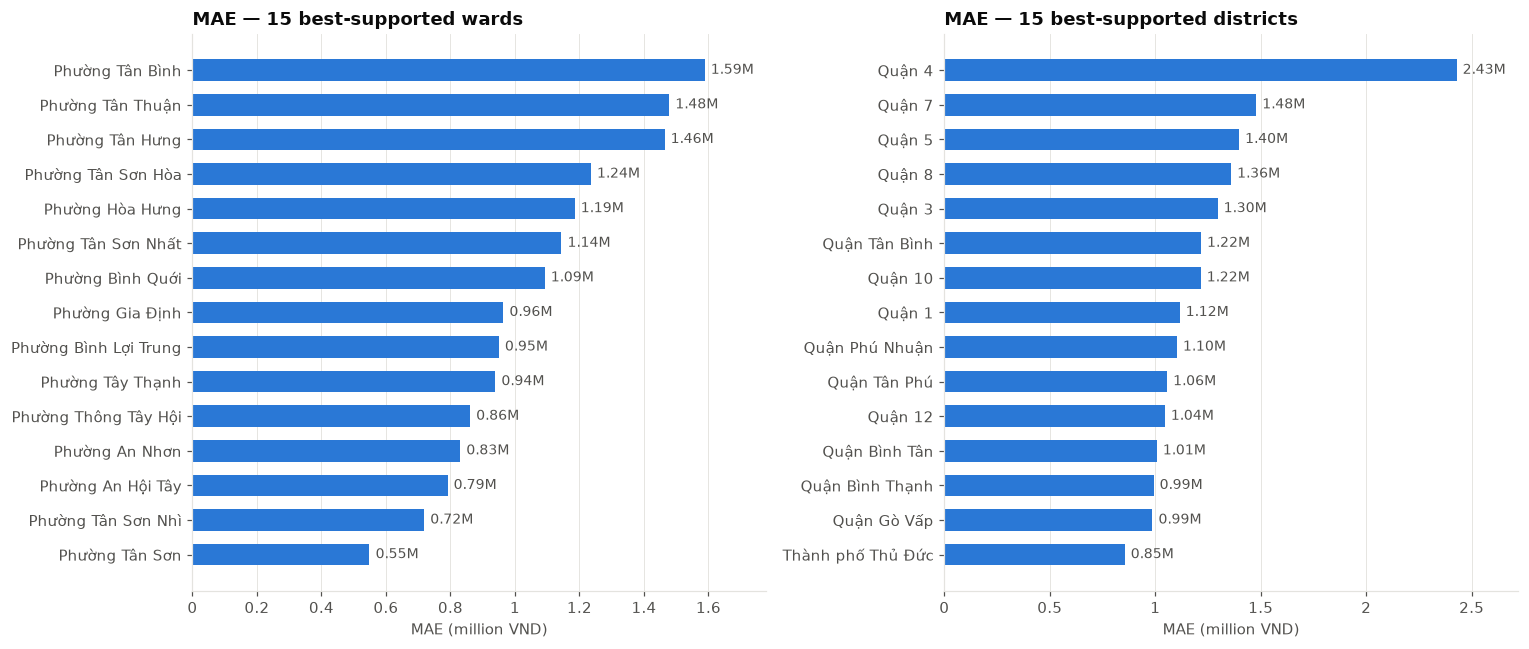

**Rows with missing location**

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Ward,__MISSING__,37153,33.089303,3800000.0,3.769520e+06,1.117145e+06,767001.129388,-56717.845573
1,District,__MISSING__,42446,37.803368,3500000.0,3.525735e+06,9.116095e+05,638284.256597,-11912.588269


In [16]:
ward_metrics = ward_diagnostics(evaluation_frame, min_support=MIN_SUPPORT, include_missing=False)
district_metrics = district_diagnostics(
    evaluation_frame, min_support=MIN_SUPPORT, include_missing=False
)
missing_loc = missing_location_summary(evaluation_frame)

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 6))
bar_chart(
    ward_metrics.sort_values("Rows", ascending=False).head(15).set_index("Segment")["MAE"] / 1e6,
    title="MAE — 15 best-supported wards",
    xlabel="MAE (million VND)",
    fmt="{:.2f}M",
    ax=left,
)
bar_chart(
    district_metrics.sort_values("Rows", ascending=False).head(15).set_index("Segment")["MAE"]
    / 1e6,
    title="MAE — 15 best-supported districts",
    xlabel="MAE (million VND)",
    fmt="{:.2f}M",
    ax=right,
)
plt.tight_layout()
plt.show()
if len(missing_loc):
    display(Markdown("**Rows with missing location**"))
    display(missing_loc)

## 17. RENT vs UNKNOWN Diagnostics

> **Why:** the PERMISSIVE policy keeps `UNKNOWN`-intent rows; check they are not much worse than explicit `RENT` rows.

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Listing Intent,RENT,79334,70.656656,4000000.0,4.035652e+06,1.076400e+06,699168.824326,-85400.409892
1,Listing Intent,UNKNOWN,32947,29.343344,3900000.0,3.939670e+06,1.086054e+06,682573.579875,71410.673112


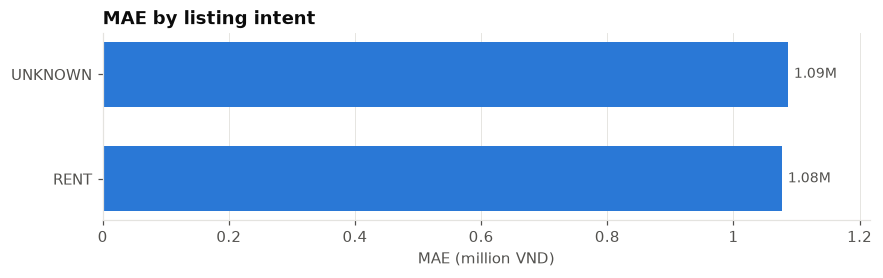

In [17]:
intent_metrics = intent_diagnostics(evaluation_frame)
display(intent_metrics)
bar_chart(
    intent_metrics.set_index("Segment")["MAE"] / 1e6,
    title="MAE by listing intent",
    xlabel="MAE (million VND)",
    fmt="{:.2f}M",
)
plt.show()

## 18. Temporal Monitoring

> **Why:** spot days where error jumps. On a historical dry run this is an integration check, not out-of-sample evidence.

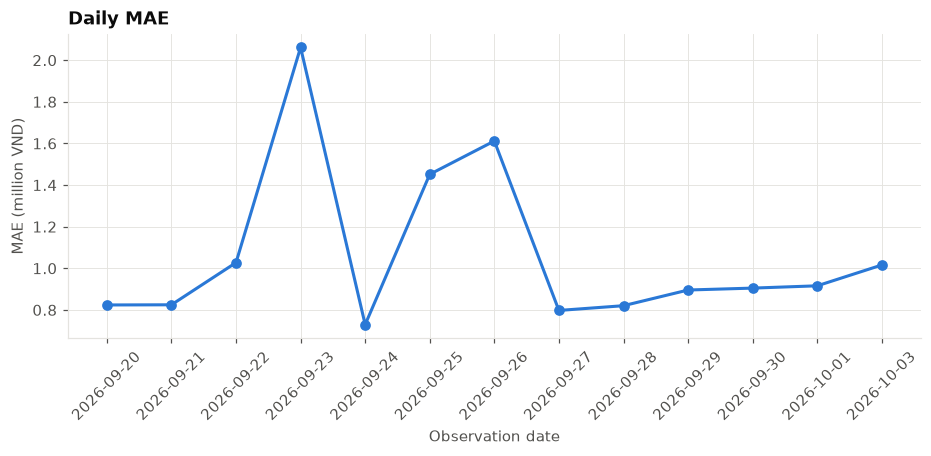

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Observation Date,2026-09-28,19622,17.475797,3600000.0,3.799548e+06,8.203892e+05,5.710982e+05,6.435436e+04
1,Observation Date,2026-09-26,19406,17.283423,4100000.0,4.667374e+06,1.611637e+06,9.953032e+05,-3.717322e+05
2,Observation Date,2026-09-22,15490,13.795745,3500000.0,3.701283e+06,1.027286e+06,7.049726e+05,2.033738e+05
3,Observation Date,2026-09-29,14416,12.839216,3800000.0,3.809506e+06,8.957516e+05,6.136031e+05,-2.729223e+04
4,Observation Date,2026-09-27,11333,10.093426,3700000.0,3.630420e+06,7.975732e+05,5.299051e+05,-1.656654e+05
5,Observation Date,2026-09-30,10947,9.749646,3600000.0,3.756525e+06,9.049030e+05,6.207602e+05,6.410048e+04
6,Observation Date,2026-09-24,8311,7.401965,4500000.0,5.004697e+06,7.294895e+05,5.046968e+05,-3.357452e+04
7,Observation Date,2026-09-23,5123,4.562660,3200000.0,4.998028e+06,2.061302e+06,1.700497e+06,1.175974e+06
8,Observation Date,2026-09-25,4595,4.092411,6500000.0,5.005291e+06,1.451555e+06,1.495303e+06,-1.385486e+06
9,Observation Date,2026-10-01,1806,1.608464,3500000.0,3.799670e+06,9.159475e+05,6.119597e+05,3.168775e+05


In [18]:
temporal_metrics = temporal_diagnostics(evaluation_frame)
temporal_order = temporal_metrics.sort_values("Segment")
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(temporal_order.Segment, temporal_order.MAE / 1e6, marker="o", color=CATEGORICAL[0])
ax.set(title="Daily MAE", xlabel="Observation date", ylabel="MAE (million VND)")
ax.grid(axis="y")
ax.tick_params(axis="x", rotation=45)
plt.show()
display(temporal_metrics)

## 19. Prediction Compression Monitoring

> **Why:** a tree model predicting the median too often squeezes the range: cheap rooms get over-priced and expensive ones under-priced.

,Population,count,min,p01,p25,median,p75,p95,p99,max,P01–P99 Span,Prediction / Actual Span
0,ACTUAL,112281,100000.000000,8.000000e+05,2.900000e+06,4.000000e+06,5.000000e+06,7.000000e+06,1.000000e+07,1.700000e+08,9.200000e+06,0.512479
1,PREDICTION,112281,514492.913765,1.826711e+06,3.412116e+06,4.003325e+06,4.999902e+06,5.637135e+06,6.541516e+06,7.197122e+06,4.714805e+06,0.512479


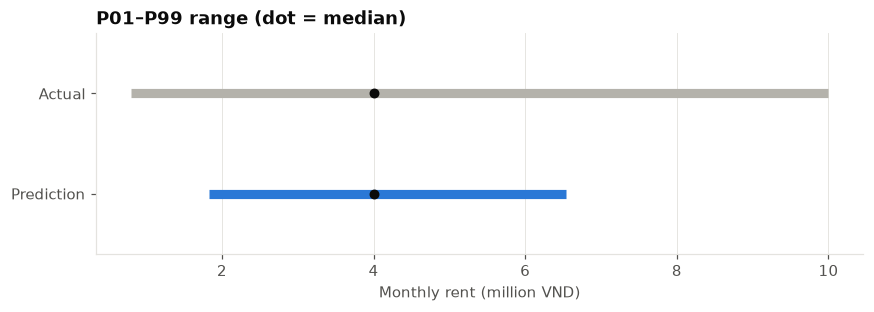

Predictions span **[1.83M, 6.54M]** (median 4.00M) while actual rents span **[0.80M, 10.00M]** (median 4.00M).

In [19]:
compression_metrics = prediction_compression_report(evaluation_frame)
display(compression_metrics)
pred_row = compression_metrics.loc[compression_metrics.Population.eq("PREDICTION")].iloc[0]
act_row = compression_metrics.loc[compression_metrics.Population.eq("ACTUAL")].iloc[0]
fig, ax = plt.subplots(figsize=(9, 2.6))
for y, (label, row, color) in enumerate(
    [("Actual", act_row, NEUTRAL), ("Prediction", pred_row, CATEGORICAL[0])]
):
    ax.hlines(y, row.p01 / 1e6, row.p99 / 1e6, color=color, linewidth=6)
    ax.scatter(row["median"] / 1e6, y, color="#0b0b0b", zorder=3, s=30)
ax.set_yticks([0, 1], ["Actual", "Prediction"])
ax.set_ylim(1.6, -0.6)
ax.set(title="P01–P99 range (dot = median)", xlabel="Monthly rent (million VND)")
plt.show()
display(
    Markdown(
        f"Predictions span **[{pred_row.p01 / 1e6:.2f}M, {pred_row.p99 / 1e6:.2f}M]** (median {pred_row['median'] / 1e6:.2f}M) "
        f"while actual rents span **[{act_row.p01 / 1e6:.2f}M, {act_row.p99 / 1e6:.2f}M]** (median {act_row['median'] / 1e6:.2f}M)."
    )
)

## 20. Production Readiness Gate

> **Why:** turn every check into PASS / NOT MET against provisional thresholds. Automated checks never promote a model to production on their own.

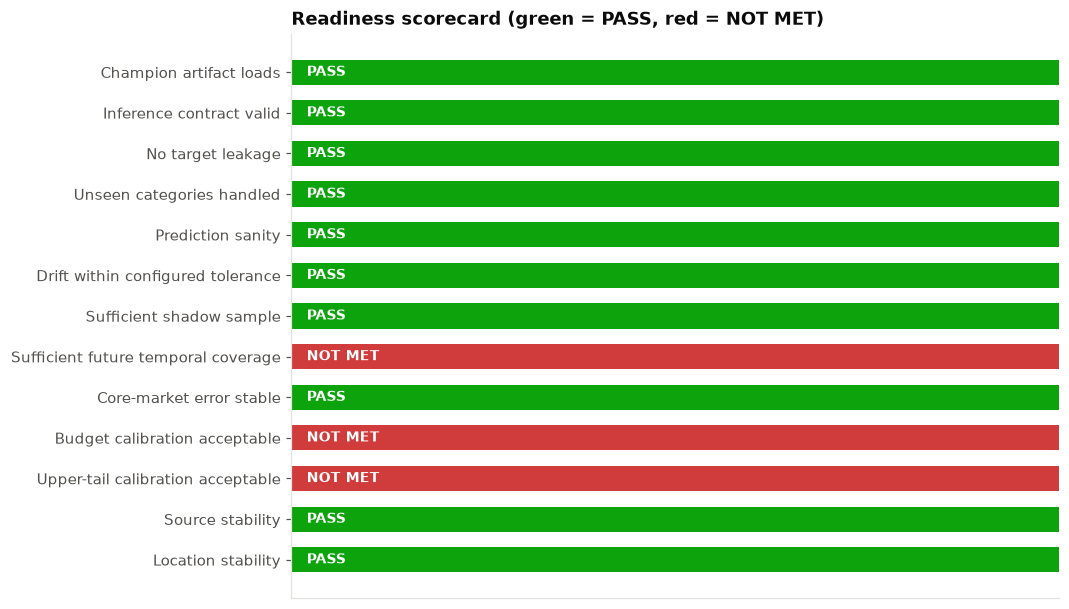

,decision
model_readiness,CANDIDATE
deployment_lifecycle,SHADOW
production_evidence,INSUFFICIENT
recommended_status,CANDIDATE
automatic_production_promotion,DISABLED
threshold_governance,PROVISIONAL_MONITORING_ONLY


In [20]:
area_row = numeric_drift.iloc[0]
max_source_shift = (
    category_share_drift.loc[category_share_drift.Feature.eq("source_code"), "Delta pp"].abs().max()
)
max_unseen_pct = category_drift["Unseen Row %"].max()
drift_within_threshold = bool(
    abs(area_row["Median Shift"])
    <= max(
        PROVISIONAL_AREA_MEDIAN_SHIFT_MAX_M2,
        PROVISIONAL_AREA_MEDIAN_SHIFT_PCT * area_row["Reference Median"],
    )
    and abs(area_row["Missing Shift pp"]) <= PROVISIONAL_AREA_MISSING_SHIFT_PP
    and max_source_shift <= PROVISIONAL_MAX_SOURCE_SHIFT_PP
    and max_unseen_pct <= PROVISIONAL_MAX_UNSEEN_CATEGORY_PCT
)


def segment_calibrated(table, label):
    row = table.loc[table.Segment.eq(label)]
    return bool(
        len(row)
        and abs(row.iloc[0]["Signed Bias"])
        <= PROVISIONAL_TAIL_BIAS_RATIO_MAX * max(row.iloc[0]["Actual Median"], 1)
    )


core_rows = price_diagnostics.loc[
    price_diagnostics.Segment.isin(["2.5M–<4.0M", "4.0M–<6.0M"])
].copy()
core_market_error_stable = bool(
    len(core_rows) == 2
    and (core_rows.MAE / core_rows["Actual Median"].clip(lower=1)).max()
    <= PROVISIONAL_CORE_MAE_RATIO_MAX
    and (core_rows["Signed Bias"].abs() / core_rows["Actual Median"].clip(lower=1)).max()
    <= PROVISIONAL_CORE_BIAS_RATIO_MAX
)
budget_calibration_acceptable = segment_calibrated(price_diagnostics, "< 2.5M")
upper_tail_calibration_acceptable = segment_calibrated(price_diagnostics, "> 10.0M")
source_stability = bool(
    len(source_metrics)
    and (
        source_metrics["Evaluation Signed Bias"].abs()
        / source_metrics["Actual Median"].clip(lower=1)
    ).max()
    <= PROVISIONAL_SOURCE_BIAS_RATIO_MAX
)
location_stability = bool(
    len(ward_metrics)
    and (ward_metrics["Signed Bias"].abs() / ward_metrics["Actual Median"].clip(lower=1)).median()
    <= PROVISIONAL_LOCATION_BIAS_RATIO_MAX
)
observed = pd.to_datetime(population.ready_rows.latest_observed_at, errors="coerce")
temporal_coverage_days = (
    (observed.max() - observed.min()).total_seconds() / 86400 if observed.notna().any() else 0
)

readiness_scorecard, readiness_decision = build_readiness_scorecard(
    validation_mode=VALIDATION_MODE,
    sample_rows=len(shadow_predictions),
    temporal_coverage_days=temporal_coverage_days,
    artifact_loaded=True,
    inference_contract_valid=True,
    no_leakage=TARGET_COLUMN not in X_shadow.columns,
    unknown_categories_safe=True,
    prediction_sanity_pass=sanity_checks.Status.eq("PASS").all(),
    drift_within_threshold=drift_within_threshold,
    core_market_error_stable=core_market_error_stable,
    budget_calibration_acceptable=budget_calibration_acceptable,
    upper_tail_calibration_acceptable=upper_tail_calibration_acceptable,
    source_stability=source_stability,
    location_stability=location_stability,
)
fig, ax = plt.subplots(figsize=(9, 0.42 * len(readiness_scorecard) + 1.2))
colors = readiness_scorecard.Status.map(
    {"PASS": STATUS["good"], "NOT MET": STATUS["critical"]}
).fillna(NEUTRAL)
ax.barh(readiness_scorecard.Dimension, np.ones(len(readiness_scorecard)), color=colors, height=0.62)
for y, status in enumerate(readiness_scorecard.Status):
    ax.text(0.02, y, status, va="center", fontsize=9, color="white", fontweight="bold")
ax.invert_yaxis()
ax.set(xlim=(0, 1), xticks=[], title="Readiness scorecard (green = PASS, red = NOT MET)")
ax.grid(False)
plt.show()
display(pd.Series(readiness_decision, name="decision").to_frame())
if VALIDATION_MODE == "HISTORICAL_DRY_RUN":
    assert readiness_decision["production_evidence"] == "INSUFFICIENT"
    assert readiness_decision["model_readiness"] == "CANDIDATE"
    assert readiness_decision["deployment_lifecycle"] == "SHADOW"

## 21. Persist Shadow Artifacts

> **Why:** keep append-only evidence per run. **Tagged `skip-execution`** so a normal run stays read-only; run it manually to record a monitoring run.

In [ ]:
RUN_ID = make_shadow_run_id(VALIDATION_MODE, INFERENCE_TIMESTAMP)
model_eligible_rows = int(
    evaluation_population.funnel.loc[
        evaluation_population.funnel.Stage.eq("Final model eligible"), "Rows"
    ].iloc[0]
)
run_metadata = {
    "run_id": RUN_ID,
    "model_id": champion.metadata["model_id"],
    "model_family": champion.metadata["model_family"],
    "feature_set": champion.metadata["feature_set"],
    "feature_names": champion.metadata["feature_names"],
    "target_transform": champion.metadata["target_transform"],
    "artifact_sha256": champion.metadata["artifact_sha256"],
    "validation_mode": VALIDATION_MODE,
    "counts_toward_production_evidence": mode_decision.counts_toward_production,
    "mode_reason": mode_decision.reason,
    "silver_sha256": CURRENT_SILVER_SHA256,
    "data_min_observed_at": mode_decision.min_observed_at,
    "data_max_observed_at": mode_decision.max_observed_at,
    "model_lock_evidence_cutoff": mode_decision.evidence_cutoff,
    "silver_rows": len(silver_df),
    "inference_ready_rows": len(shadow_predictions),
    "model_eligible_rows": model_eligible_rows,
    "evaluation_rows": len(evaluation_frame),
    "excluded_from_inference_rows": len(silver_df) - len(shadow_predictions),
    "excluded_from_evaluation_rows": len(silver_df) - model_eligible_rows,
    "temporal_coverage_days": temporal_coverage_days,
    "feature_drift_summary": numeric_drift.iloc[0].to_dict(),
    "category_drift_summary": category_drift.to_dict("records"),
    "prediction_distribution": prediction_distribution_table.iloc[0].to_dict(),
    "overall_metrics": overall_metrics.iloc[0].to_dict(),
    "provisional_monitoring_thresholds": {
        "minimum_sample_rows": PROVISIONAL_MIN_SAMPLE_ROWS,
        "minimum_future_days": PROVISIONAL_MIN_FUTURE_DAYS,
        "area_median_shift": f"<= max({PROVISIONAL_AREA_MEDIAN_SHIFT_MAX_M2}m², {int(PROVISIONAL_AREA_MEDIAN_SHIFT_PCT * 100)}% of reference median)",
        "area_missing_shift_pp": PROVISIONAL_AREA_MISSING_SHIFT_PP,
        "source_share_shift_pp": PROVISIONAL_MAX_SOURCE_SHIFT_PP,
        "unseen_category_rows_pct": PROVISIONAL_MAX_UNSEEN_CATEGORY_PCT,
        "budget_and_upper_tail_absolute_bias_pct": int(PROVISIONAL_TAIL_BIAS_RATIO_MAX * 100),
        "source_and_location_bias_pct": int(PROVISIONAL_SOURCE_BIAS_RATIO_MAX * 100),
    },
    "model_readiness": readiness_decision["model_readiness"],
    "deployment_lifecycle": readiness_decision["deployment_lifecycle"],
    "production_evidence": readiness_decision["production_evidence"],
    "recommended_status": readiness_decision["recommended_status"],
    "inference_timestamp": INFERENCE_TIMESTAMP,
}
artifact_tables = {
    "inference_population_funnel": population.funnel,
    "evaluation_population_funnel": evaluation_population.funnel,
    "evaluation_exclusion_summary": evaluation_population.exclusion_summary,
    "schema_validation": population.schema_summary,
    "numeric_feature_drift": numeric_drift,
    "category_share_drift": category_share_drift,
    "category_drift": category_drift,
    "prediction_distribution": prediction_distribution_table,
    "prediction_reference_comparison": prediction_reference_comparison,
    "prediction_sanity": sanity_checks,
    "overall_metrics": overall_metrics,
    "price_bucket_metrics": price_diagnostics,
    "area_bucket_metrics": area_diagnostics,
    "source_metrics": source_metrics,
    "ward_metrics": ward_metrics,
    "district_metrics": district_metrics,
    "missing_location_metrics": missing_loc,
    "intent_metrics": intent_metrics,
    "temporal_metrics": temporal_metrics,
    "prediction_compression": compression_metrics,
    "readiness_scorecard": readiness_scorecard,
}
RUN_DIR = persist_shadow_run(
    SHADOW_OUTPUT_ROOT, RUN_ID, run_metadata, shadow_output, artifact_tables
)
display(Markdown(f"Append-only shadow evidence written to `{RUN_DIR.relative_to(PROJECT_ROOT)}`."))

## 22. Final Summary

In [21]:
model_eligible_rows = int(
    evaluation_population.funnel.loc[
        evaluation_population.funnel.Stage.eq("Final model eligible"), "Rows"
    ].iloc[0]
)
metrics = overall_metrics.iloc[0]
passed = int(readiness_scorecard.Status.eq("PASS").sum())
display(
    Markdown(
        f"""
**Key findings**

- Champion `{champion.metadata['model_id']}` loaded with a verified hash; the inference contract and target-free F4 matrix pass.
- Scored **{len(shadow_predictions):,}** inference-ready listings; **{model_eligible_rows:,}** could be evaluated against trusted rent.
- Mode **{VALIDATION_MODE}** — {"counts" if mode_decision.counts_toward_production else "does **not** count"} toward production evidence.
- Error on this batch: MAE **{metrics['MAE']:,.0f} VND**, R² **{metrics['R²']:.2f}**; predictions are compressed toward the median
  ({pred_row.p01 / 1e6:.1f}–{pred_row.p99 / 1e6:.1f}M vs actual {act_row.p01 / 1e6:.1f}–{act_row.p99 / 1e6:.1f}M).
- Readiness gate: **{passed}/{len(readiness_scorecard)}** checks pass → model **{readiness_decision['model_readiness']}**,
  lifecycle **{readiness_decision['deployment_lifecycle']}**, production evidence **{readiness_decision['production_evidence']}**.

**Next evidence needed:** 30–60 days of untouched post-lock crawls, with stable source/location error and explicit
monitoring of low-price over-prediction and upper-tail under-prediction.
"""
    )
)


**Key findings**

- Champion `roombeacon-price-lgbm-f4-raw-0b0c9d9fa450` loaded with a verified hash; the inference contract and target-free F4 matrix pass.
- Scored **129,112** inference-ready listings; **112,281** could be evaluated against trusted rent.
- Mode **HISTORICAL_DRY_RUN** — does **not** count toward production evidence.
- Error on this batch: MAE **1,079,233 VND**, R² **0.27**; predictions are compressed toward the median
  (1.8–6.5M vs actual 0.8–10.0M).
- Readiness gate: **10/13** checks pass → model **CANDIDATE**,
  lifecycle **SHADOW**, production evidence **INSUFFICIENT**.

**Next evidence needed:** 30–60 days of untouched post-lock crawls, with stable source/location error and explicit
monitoring of low-price over-prediction and upper-tail under-prediction.
